# M1.Ex2: Model Experience vs Salary

- Run: Open In Colab
- Raw Dataset: Salary Data.csv


In [3]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [33]:
db = pd.read_csv('https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv')
db.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables X to the features and y to the target

In [8]:
X= db[['Experience Years']]
y= db['Salary']


### Step 2.b print the type of each

In [22]:
X.dtypes

Experience Years    float64
dtype: object

In [10]:
y.dtype

dtype('int64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Target is numerical 
Task is Regression 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [11]:
X.shape

(40, 1)

In [12]:
y.shape

(40,)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [13]:
db.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

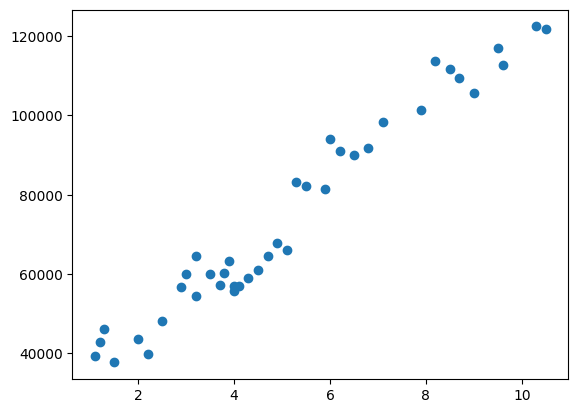

In [15]:
import matplotlib.pyplot as plt
plt.scatter(db['Experience Years'], db['Salary'])

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship between years of experience and salary is a positive/increasing relationship.

### Step 7. Initialize a regression model

In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Step 8. Split the dataset into train and test sets


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    )



### Step 9.a Train the model on the training set


In [24]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [ ]:
slop=model.coef_[0]################
intercept = model.intercept_
print('slop = ',slop)
print('intercept =',intercept)

slop =  9408.03127250658
intercept = 26716.250176145535


### Step 9.c how much salary does a person get with 2 years of experience?


In [27]:
model.predict([[2]])

/home/mona/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([45532.31272116])

**Note:** Salary=(Slope×2)+Intercept

### Step 9.d how much does an increase of 6 months of experience adds to a person’s salary?

In [28]:
print('increase = ',slop/2)

increase =  4704.01563625329


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [30]:
print('salary =',intercept.round())

salary = 26716.0


### Step 10. Evaluate the model on the test set

In [40]:
from sklearn.metrics import mean_squared_error, r2_score


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 48077731.17
R2 Score: 0.9069


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [44]:
sample_X = X_test.head(3)
sample_y_true = y_test.head(3)

sample_y_pred = model.predict(sample_X)


comparison = pd.DataFrame({
    'Experience': sample_X.values.flatten(),
    'True Salary': sample_y_true.values,
    'Predicted Salary': sample_y_pred,
    'Difference (Error)': sample_y_pred - sample_y_true.values
    
})

print(comparison)

   Experience  True Salary  Predicted Salary  Difference (Error)
0         4.5        61111      69052.390902         7941.390902
1         4.0        56957      64348.375266         7391.375266
2         4.0        55794      64348.375266         8554.375266


### Step 12. Plot the data and the regression line

Text(0, 0.5, 'Salary')

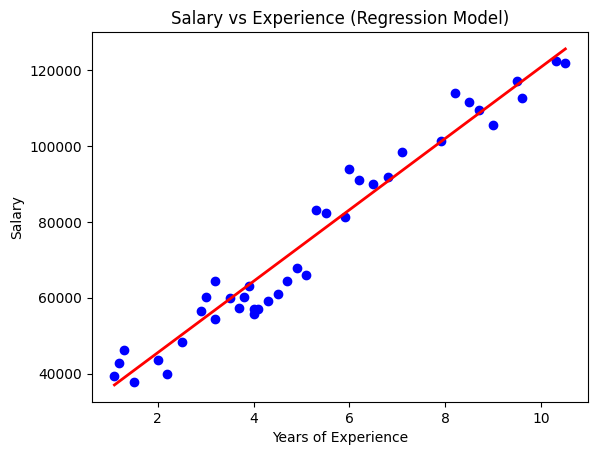

In [45]:
plt.scatter(X, y, color='blue', label='Actual Employees')

plt.plot(X, model.predict(X), color='red', linewidth=2, label='Model Prediction Line')

plt.title('Salary vs Experience (Regression Model)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')